In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import seaborn as sns

df = pd.read_csv("data/pa_data.csv")
temps = pd.read_csv("data/pa_temps_supplement.csv")
df = df.merge(temps, on=["station_id", "year"], how="left")

df = df[df['year'] >= 1960]

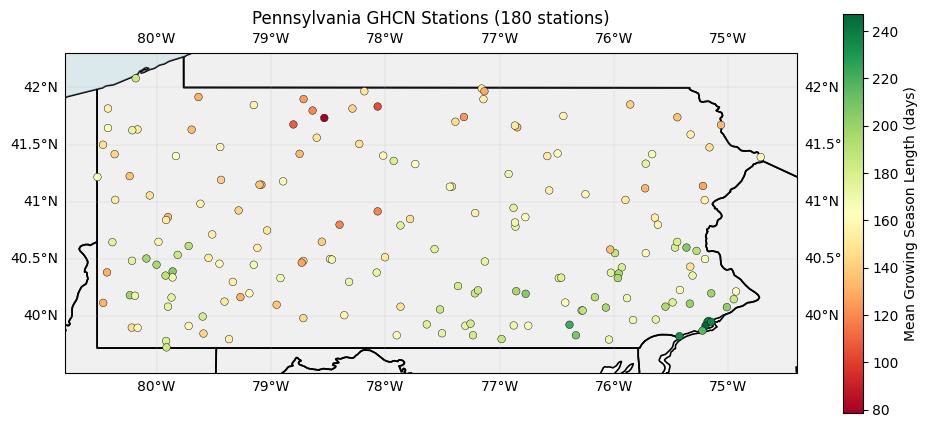

In [2]:
stations = df.groupby("station_id").agg(
    name=("station_name", "first"),
    lat=("latitude", "first"),
    lon=("longitude", "first"),
    elev_m=("elevation_m", "first"),
    first_year=("year", "min"),
    last_year=("year", "max"),
    n_years=("year", "count"),
    mean_gsl=("growing_season_length", "mean"),
).reset_index()

plt.figure(figsize=(10,6))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent([-80.8, -74.4, 39.5, 42.3])
ax.add_feature(cfeature.STATES, edgecolor="black", linewidth=1.2)
ax.add_feature(cfeature.LAKES, alpha=0.3, facecolor="lightblue")
ax.add_feature(cfeature.LAND, facecolor="#f0f0f0")

sc = plt.scatter(stations["lon"], stations["lat"], c=stations["mean_gsl"],
                    cmap="RdYlGn", s=30, edgecolors="k", linewidths=0.3,
                    transform=ccrs.PlateCarree(), zorder=5)
plt.colorbar(sc, label="Mean Growing Season Length (days)", shrink=0.7)
ax.set_title(f"Pennsylvania GHCN Stations ({len(stations)} stations)")
ax.gridlines(draw_labels=True, linewidth=0.3, alpha=0.5)

plt.tight_layout()
plt.show()

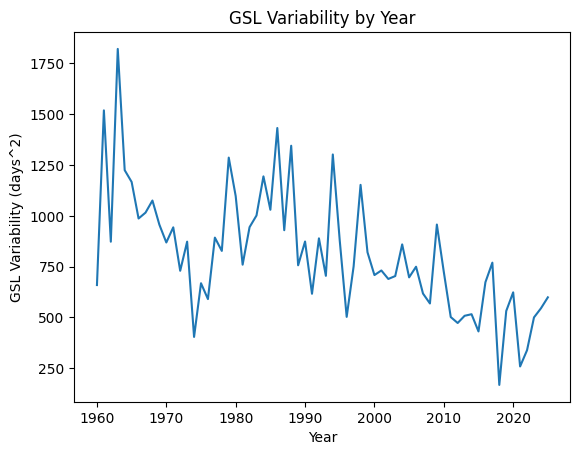

In [3]:
gsl_variability_by_year = df.groupby('year')['growing_season_length'].var()
plt.plot(gsl_variability_by_year)
plt.xlabel('Year')
plt.ylabel('GSL Variability (days^2)')
plt.title('GSL Variability by Year')
plt.show()

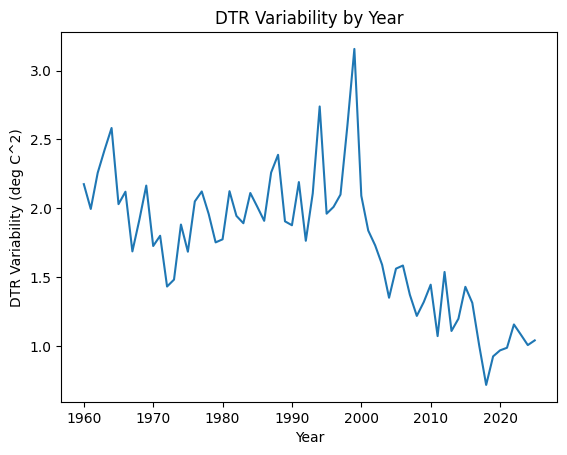

In [4]:
dtr_variability_by_year = df.groupby('year')['dtr_annual'].var()
plt.plot(dtr_variability_by_year)
plt.xlabel('Year')
plt.ylabel('DTR Variability (deg C^2)')
plt.title('DTR Variability by Year')
plt.show()

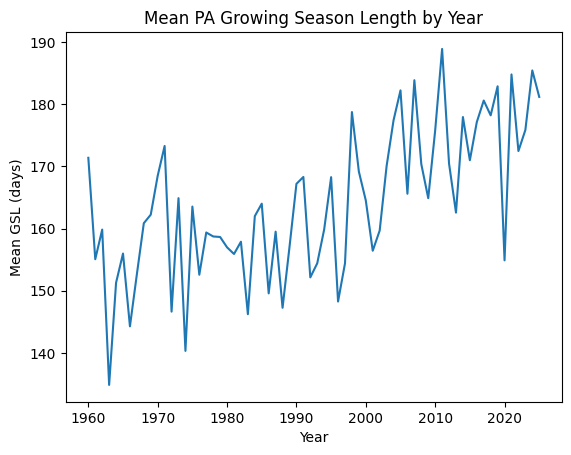

In [5]:
gsl_mean_by_year = df.groupby('year')['growing_season_length'].mean()
plt.plot(gsl_mean_by_year)
plt.xlabel('Year')
plt.ylabel('Mean GSL (days)')
plt.title('Mean PA Growing Season Length by Year')
plt.show()

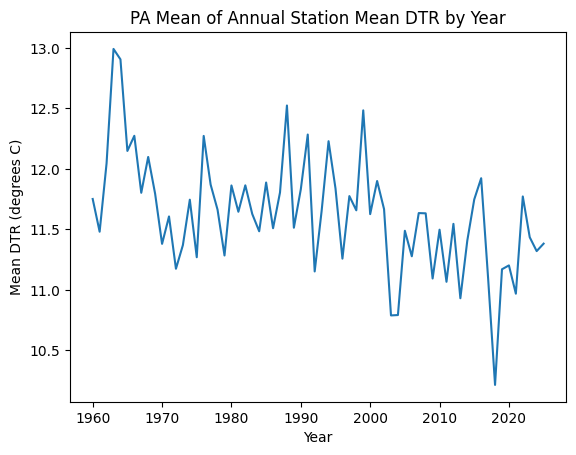

In [6]:
dtr_mean_by_year = df.groupby('year')['dtr_annual'].mean()
plt.plot(dtr_mean_by_year)
plt.xlabel('Year')
plt.ylabel('Mean DTR (degrees C)')
plt.title('PA Mean of Annual Station Mean DTR by Year')
plt.show()

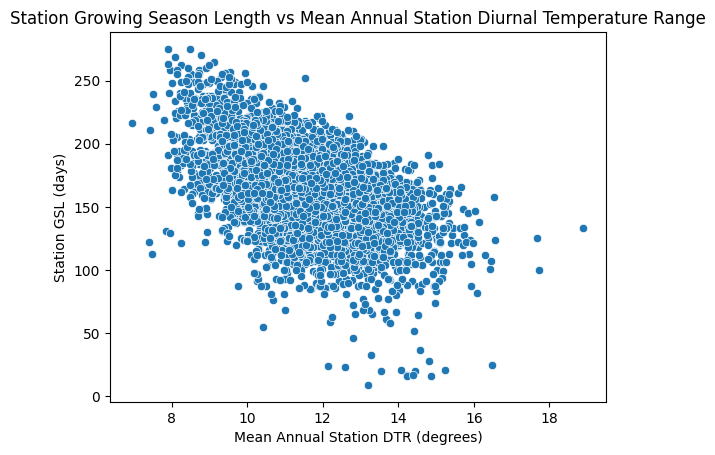

In [7]:
sns.scatterplot(data = df, x= 'dtr_annual', y= 'growing_season_length')
plt.xlabel('Mean Annual Station DTR (degrees)')
plt.ylabel('Station GSL (days)')
plt.title('Station Growing Season Length vs Mean Annual Station Diurnal Temperature Range')
plt.show()

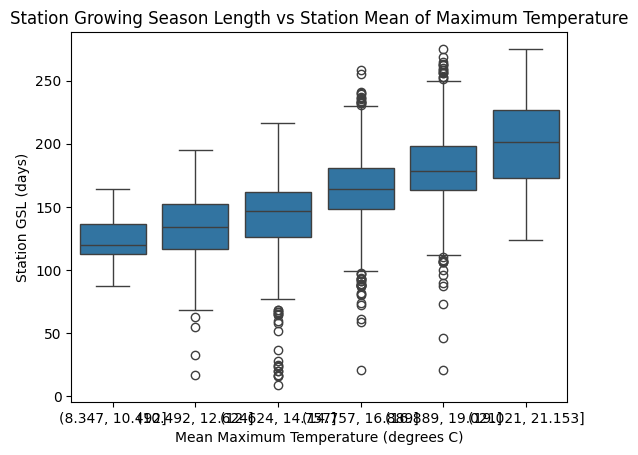

In [8]:
df_temp_cleaned = df[df['tmax_annual']> 5]
df_temp_cleaned['bins'] = pd.cut(x= df_temp_cleaned['tmax_annual'], bins = 6)
df_temp_cleaned.sort_values(by = 'bins')
sns.boxplot(data = df_temp_cleaned, x= 'bins', y='growing_season_length')
plt.xlabel('Mean Maximum Temperature (degrees C)')
plt.ylabel('Station GSL (days)')
plt.title('Station Growing Season Length vs Station Mean of Maximum Temperature')
plt.show()

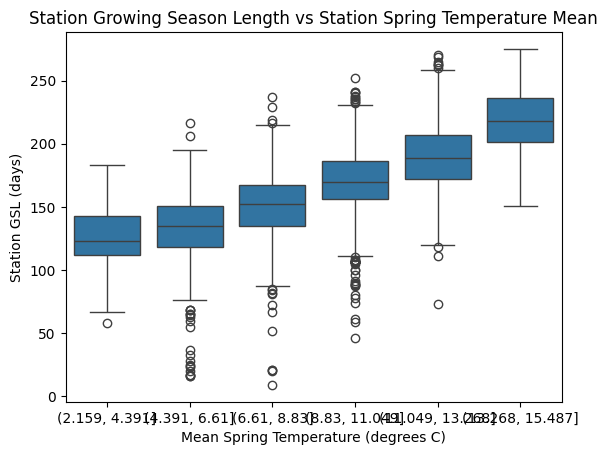

In [9]:
df_spring_temp = df.copy()
df_spring_temp['bins'] = pd.cut(x= df_spring_temp['tmean_spring'], bins = 6)
df_spring_temp.sort_values(by = 'bins')
sns.boxplot(data = df_spring_temp, x= 'bins', y='growing_season_length')
plt.xlabel('Mean Spring Temperature (degrees C)')
plt.ylabel('Station GSL (days)')
plt.title('Station Growing Season Length vs Station Spring Temperature Mean')
plt.show()

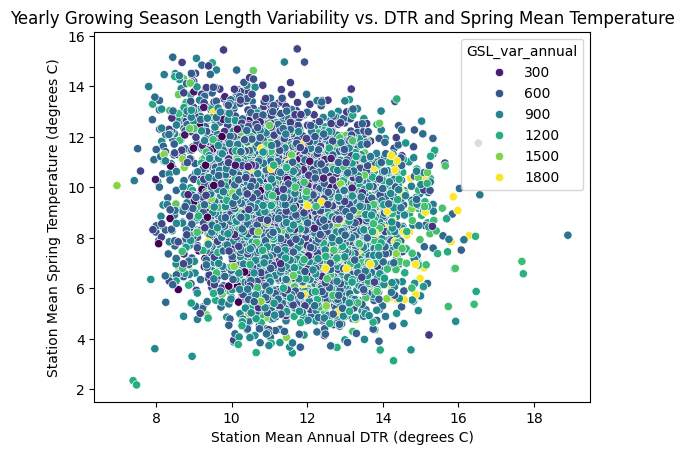

In [10]:
gsl_variability_by_year = df.groupby('year')['growing_season_length'].var()
dtr_mean_by_year = df.groupby('year')['dtr_annual'].mean()

df['GSL_var_annual'] = df['year'].map(gsl_variability_by_year)
df['DTR_mean_annual'] = df['year'].map(dtr_mean_by_year)

sns.scatterplot(data=df, x='dtr_annual', y='tmean_spring', hue='GSL_var_annual', palette = 'viridis')
plt.xlabel('Station Mean Annual DTR (degrees C)')
plt.ylabel('Station Mean Spring Temperature (degrees C)')
plt.title('Yearly Growing Season Length Variability vs. DTR and Spring Mean Temperature')
plt.show()

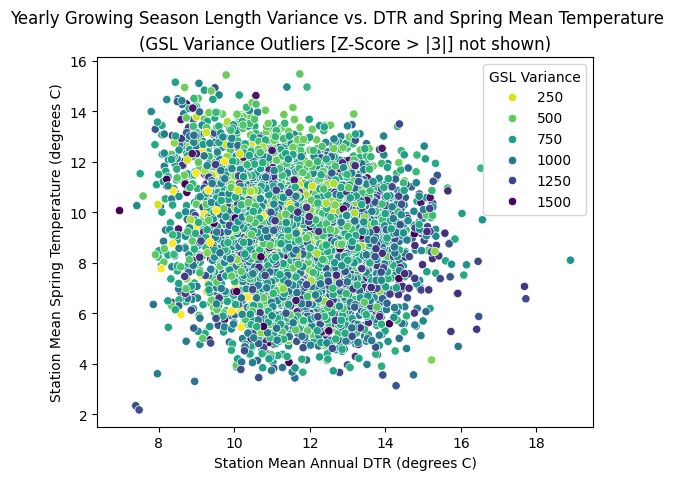

In [11]:
df['GSL_var_zscore'] = (df['GSL_var_annual'] - df['GSL_var_annual'].mean()) / df['GSL_var_annual'].std()
df_GSL_var_outliers_dropped = df[df['GSL_var_zscore'].between(-3,3)]

sns.scatterplot(data=df_GSL_var_outliers_dropped, x='dtr_annual', y='tmean_spring', hue='GSL_var_annual', palette = 'viridis_r')
plt.xlabel('Station Mean Annual DTR (degrees C)')
plt.ylabel('Station Mean Spring Temperature (degrees C)')
plt.suptitle('Yearly Growing Season Length Variance vs. DTR and Spring Mean Temperature')
plt.title('(GSL Variance Outliers [Z-Score > |3|] not shown)')
plt.legend(title = "GSL Variance")
plt.show()

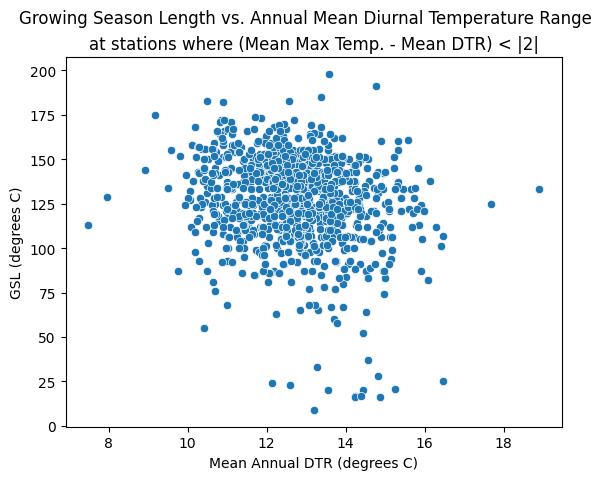

In [24]:
df_critical_range_test = df.copy()
df_critical_range_test['DTR_lower_end'] = df_critical_range_test['tmax_annual'] - df_critical_range_test['dtr_annual']
df_critical_range = df_critical_range_test[df_critical_range_test['DTR_lower_end'].between(-2,2)]

sns.scatterplot(data = df_critical_range, x = 'dtr_annual', y = 'growing_season_length')
plt.xlabel("Mean Annual DTR (degrees C)")
plt.ylabel("GSL (degrees C)")
plt.suptitle("Growing Season Length vs. Annual Mean Diurnal Temperature Range")
plt.title("at stations where (Mean Max Temp. - Mean DTR) < |2|")
plt.show()